In [1]:
!pip install sentence-transformers seaborn

In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
sentences = [
    "The batsman scored a century in the match",
    "The bowler took five wickets in the game",
    "The cricket team celebrated their victory",
    "The spinner delivered a googly that foxed the batsman",
    "I added spices while cooking the curry",
    "The chef prepared a delicious pasta dish",
    "Baking a cake requires flour, sugar, and eggs",
    "Strong passwords help protect online accounts",
    "Phishing attacks try to steal sensitive information",
    "A SQL injection vulnerability was found in the web application",
]

labels = [
    'Cricket-1', 'Cricket-2', 'Cricket-3', 'Cricket-4',
    'Cooking-1', 'Cooking-2', 'Cooking-3',
    'CyberSec-1', 'CyberSec-2', 'CyberSec-3'
]

print(f'Total sentences: {len(sentences)}')
for i, (label, sent) in enumerate(zip(labels, sentences)):
    print(f'[{i}] {label:<12}: {sent}')

Total sentences: 10
[0] Cricket-1   : The batsman scored a century in the match
[1] Cricket-2   : The bowler took five wickets in the game
[2] Cricket-3   : The cricket team celebrated their victory
[3] Cricket-4   : The spinner delivered a googly that foxed the batsman
[4] Cooking-1   : I added spices while cooking the curry
[5] Cooking-2   : The chef prepared a delicious pasta dish
[6] Cooking-3   : Baking a cake requires flour, sugar, and eggs
[7] CyberSec-1  : Strong passwords help protect online accounts
[8] CyberSec-2  : Phishing attacks try to steal sensitive information
[9] CyberSec-3  : A SQL injection vulnerability was found in the web application


In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print('Number of sentences:', len(sentences))
print('Embedding shape:', embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Number of sentences: 10
Embedding shape: (10, 384)


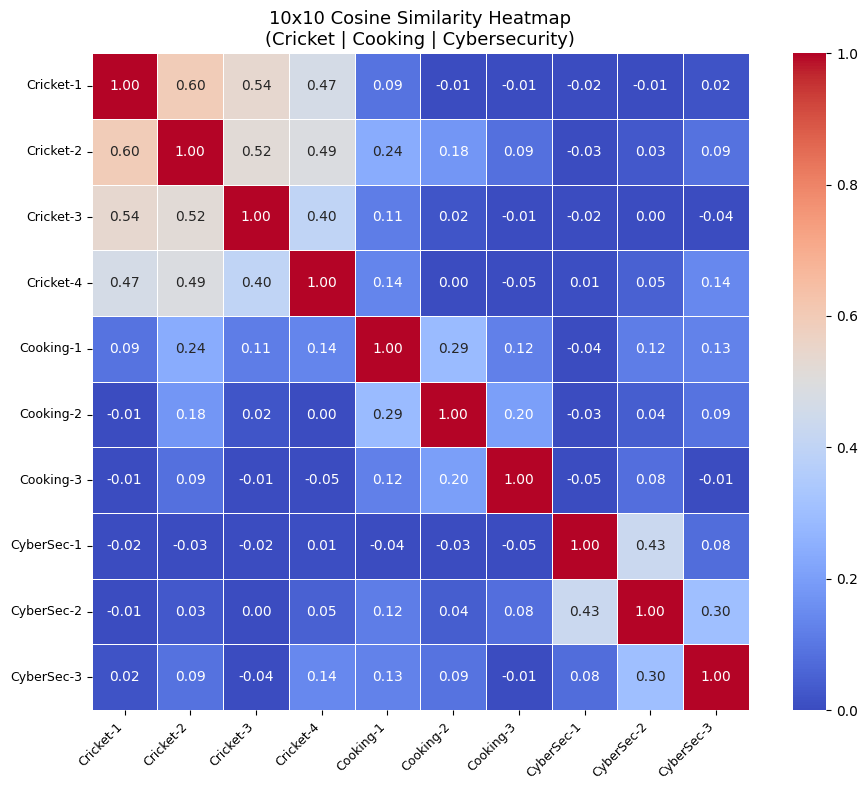

In [5]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    xticklabels=labels,
    yticklabels=labels,
    vmin=0, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('10x10 Cosine Similarity Heatmap\n(Cricket | Cooking | Cybersecurity)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])
similarities = cosine_similarity(query_embedding, embeddings)[0]
top_indices = similarities.argsort()[-2:][::-1]

print('Query:', query)
print('\nTop 2 most similar sentences:\n')
for rank, i in enumerate(top_indices, start=1):
    print(f'Rank {rank}:')
    print(f'  Sentence : {sentences[i]}')
    print(f'  Label    : {labels[i]}')
    print(f'  Similarity Score: {similarities[i]:.4f}')
    print()

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Rank 1:
  Sentence : The bowler took five wickets in the game
  Label    : Cricket-2
  Similarity Score: 0.8470

Rank 2:
  Sentence : The batsman scored a century in the match
  Label    : Cricket-1
  Similarity Score: 0.5682

